In [82]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pandas as pd
from PIL import Image
import torch
import cv2
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

In [83]:
plt.style.use('default')
sns.set_palette("husl")

In [84]:
!ls ./data/coco_search18_tp/

fixations  images     processed  readme.txt saccades


In [85]:
def analyze_raw_data(data_root=Path('./data/coco_search18_tp'), output_dir = Path('./visualizations')):
    """Analyze and visualize raw JSON data structure"""
    fixations_dir = data_root / 'fixations'
    
    
    # Load raw fixation data
    json_files = list(fixations_dir.glob('*train*.json'))
    if not json_files:
        print("❌ No training JSON files found!")
        return
    
    all_trials = []
    for json_file in json_files:
        with open(json_file, 'r') as f:
            trials = json.load(f)
            all_trials.extend(trials)
    
    print(f"📈 Total trials loaded: {len(all_trials)}")
    
    # Analyze trial structure
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # 1. Sequence length distribution
    seq_lengths = [len(trial.get('X', [])) for trial in all_trials if 'X' in trial]
    axes[0,0].hist(seq_lengths, bins=25, edgecolor='black', alpha=0.7)
    axes[0,0].set_xlabel('Sequence Length (fixations)')
    axes[0,0].set_ylabel('Count')
    # set max x as max sequence length
    print(f"Max sequence length: {max(seq_lengths)}")
    axes[0,0].set_xlim(0, max(seq_lengths) + 1)
    
    axes[0,0].set_title('Distribution of Scanpath Lengths')
    axes[0,0].axvline(np.mean(seq_lengths), color='red', linestyle='--', 
                        label=f'Mean: {np.mean(seq_lengths):.1f}')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)
    
    # 2. Target object distribution
    targets = [trial.get('task', 'unknown') for trial in all_trials]
    target_counts = pd.Series(targets).value_counts().head(15)
    target_counts.plot(kind='barh', ax=axes[0,1])
    axes[0,1].set_title('Top 15 Target Objects')
    axes[0,1].set_xlabel('Count')
    
    # 3. Success rate by target
    target_success = {}
    for trial in all_trials:
        target = trial.get('task', 'unknown')
        success = trial.get('correct', False)
        if target not in target_success:
            target_success[target] = {'total': 0, 'success': 0}
        target_success[target]['total'] += 1
        if success:
            target_success[target]['success'] += 1
    
    # Calculate success rates for targets with >10 trials
    success_rates = []
    target_names = []
    for target, stats in target_success.items():
        if stats['total'] >= 10:
            rate = stats['success'] / stats['total']
            success_rates.append(rate)
            target_names.append(target)
    
    # Sort by success rate
    sorted_data = sorted(zip(success_rates, target_names), reverse=True)
    rates, names = zip(*sorted_data[:15])
    
    bars = axes[0,2].barh(range(len(names)), rates)
    axes[0,2].set_yticks(range(len(names)))
    axes[0,2].set_yticklabels(names)
    axes[0,2].set_xlabel('Success Rate')
    axes[0,2].set_title('Success Rate by Target (n≥10)')
    
    # Color bars by success rate
    for bar, rate in zip(bars, rates):
        bar.set_color('green' if rate > 0.7 else 'orange' if rate > 0.4 else 'red')
    
    # 4. Coordinate distribution heatmap
    all_x = []
    all_y = []
    for trial in all_trials[:1000]:  # Sample for speed
        if 'X' in trial and 'Y' in trial:
            X = [x/1920 for x in trial['X']]  # Normalize to [0,1]
            Y = [y/1080 for y in trial['Y']]
            all_x.extend(X)
            all_y.extend(Y)
    
    h, xedges, yedges = np.histogram2d(all_x, all_y, bins=50, 
                                        range=[[0,1], [0,1]], density=True)
    im = axes[1,0].imshow(h.T, origin='lower', extent=[0,1,0,1], 
                            cmap='hot', aspect='equal')
    axes[1,0].set_title('Overall Fixation Density')
    axes[1,0].set_xlabel('X (normalized)')
    axes[1,0].set_ylabel('Y (normalized)')
    plt.colorbar(im, ax=axes[1,0])
    
    # 5. Temporal dynamics
    time_steps = []
    positions = []
    for trial in all_trials[:100]:  # Sample for speed
        if 'X' in trial and 'Y' in trial and len(trial['X']) >= 10:
            X = np.array(trial['X']) / 1920
            Y = np.array(trial['Y']) / 1080
            for t, (x, y) in enumerate(zip(X[:10], Y[:10])):
                time_steps.append(t)
                positions.append(np.sqrt(x**2 + y**2))  # Distance from origin
    
    df_temp = pd.DataFrame({'time': time_steps, 'distance': positions})
    df_temp.groupby('time')['distance'].mean().plot(ax=axes[1,1], marker='o')
    axes[1,1].set_title('Average Distance from Origin Over Time')
    axes[1,1].set_xlabel('Time Step')
    axes[1,1].set_ylabel('Distance from Origin')
    axes[1,1].grid(True, alpha=0.3)
    
    # 6. Subject distribution
    subjects = [trial.get('subject', 'unknown') for trial in all_trials]
    subject_counts = pd.Series(subjects).value_counts()
    subject_counts.head(10).plot(kind='bar', ax=axes[1,2])
    axes[1,2].set_title('Top 10 Subjects by Trial Count')
    axes[1,2].set_xlabel('Subject ID')
    axes[1,2].set_ylabel('Number of Trials')
    axes[1,2].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Save statistics
    stats = {
        'total_trials': len(all_trials),
        'avg_sequence_length': float(np.mean(seq_lengths)),
        'std_sequence_length': float(np.std(seq_lengths)),
        'num_unique_targets': len(set(targets)),
        'num_unique_subjects': len(set(subjects)),
        'overall_success_rate': sum(trial.get('correct', False) for trial in all_trials) / len(all_trials)
    }
    
    print(f"📊 Raw data analysis complete. Stats: {stats}")
    

📈 Total trials loaded: 42485
Max sequence length: 41


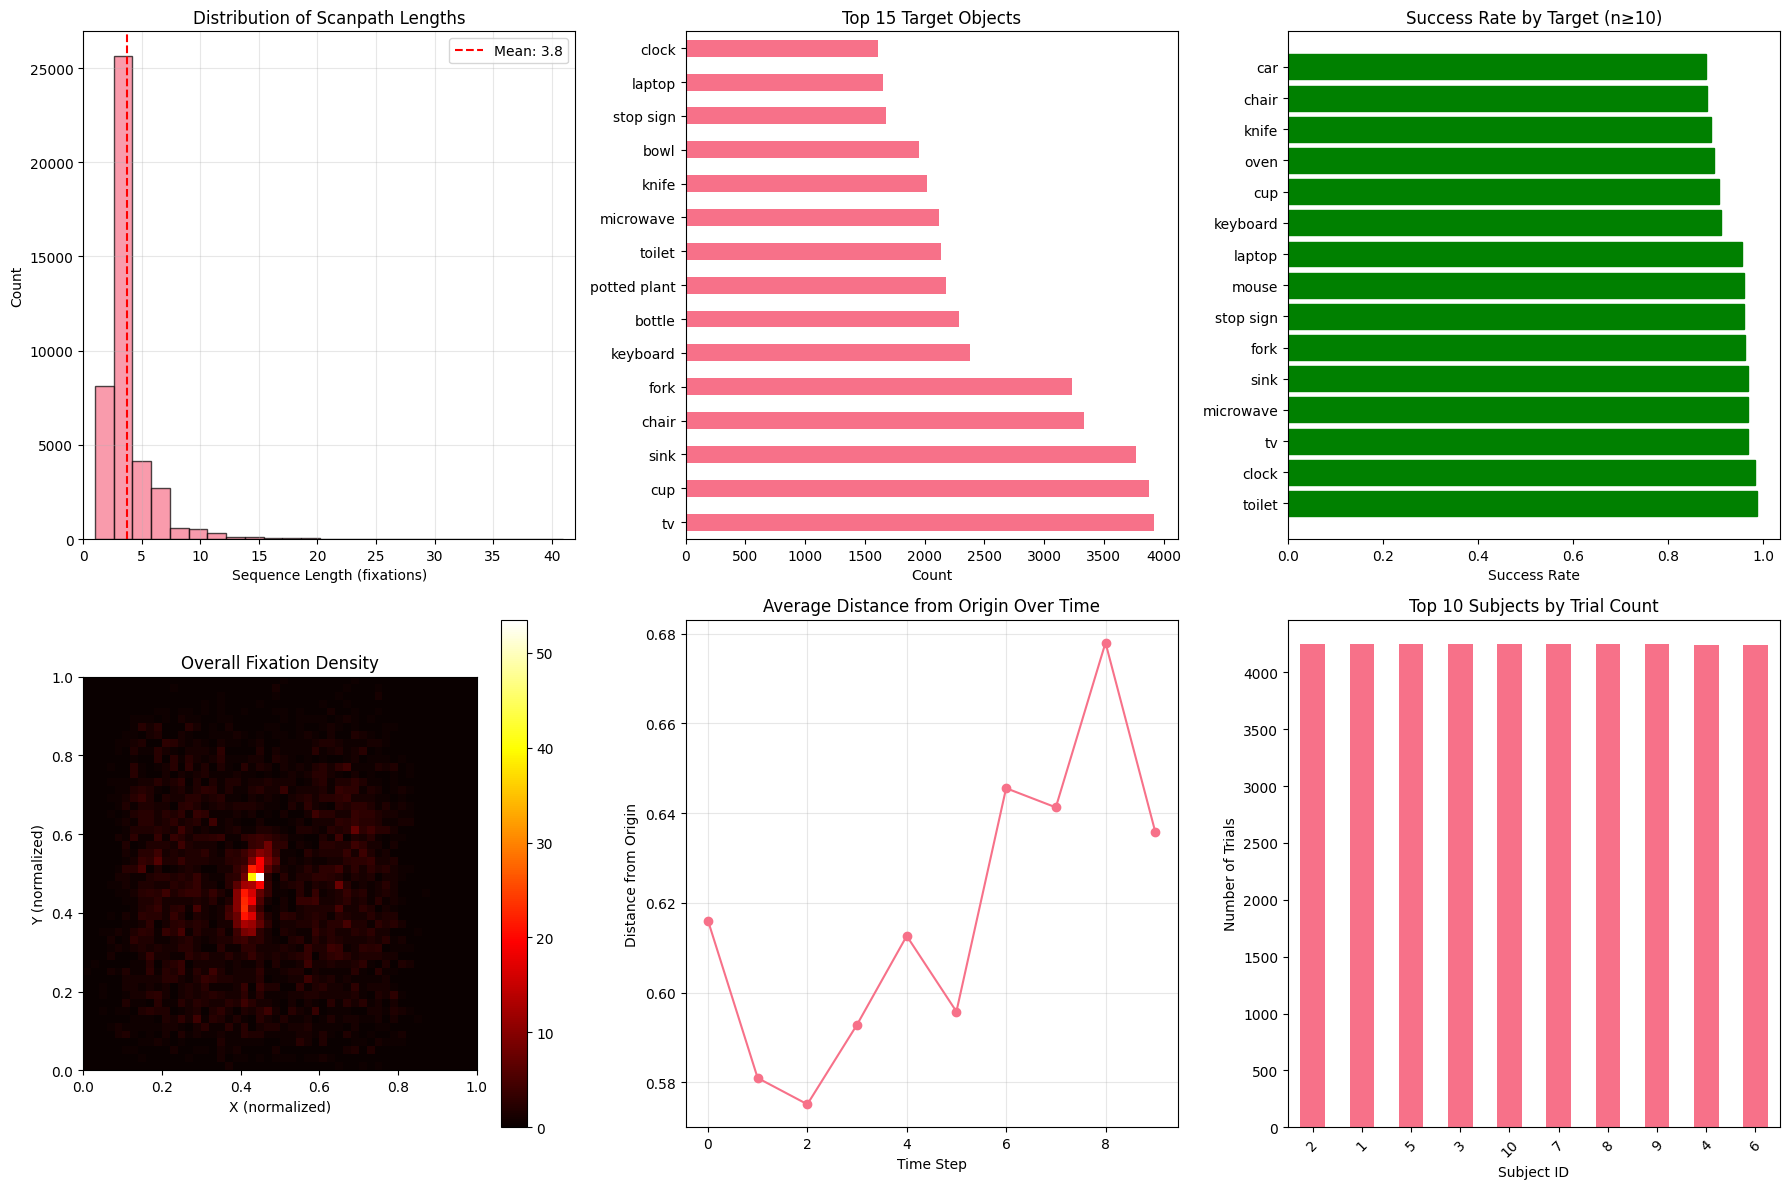

📊 Raw data analysis complete. Stats: {'total_trials': 42485, 'avg_sequence_length': 3.7825350123573025, 'std_sequence_length': 2.134832703952547, 'num_unique_targets': 18, 'num_unique_subjects': 10, 'overall_success_rate': 0.9211015652583264}


In [86]:
analyze_raw_data()

In [87]:
data_root = Path('./data/coco_search18_tp')
processed_dir = data_root / 'processed'
fixations_dir = data_root / 'fixations'
images_dir = data_root / 'images'

In [ ]:
def check_data_scale():
    """Quick data scale check"""
    configs = ['short', 'medium', 'standard', 'success_only']
    for config in configs:
        if config == 'standard':
            seq_file = processed_dir / f'train_sequences.npy'
        else:
            seq_file = processed_dir / f'{config}_train_sequences.npy'
        if seq_file.exists():
            sequences = np.load(seq_file)
            print(f"{config}: {sequences.shape[0]} sequences, shape {sequences.shape}")
        else:
            print(f"{config}: not found")

check_data_scale()

short: 4535 sequences, shape (4535, 10, 2)
medium: 258 sequences, shape (258, 40, 2)
standard: not found
success_only: 0 sequences, shape (0,)


In [89]:
json_files = list(fixations_dir.glob('*train*.json'))
if json_files:
    with open(json_files[0], 'r') as f:
        original_trials = json.load(f)
    print(f"Original trials: {len(original_trials)}")
    print(f"Sample trial keys: {list(original_trials[0].keys())}")
else:
    original_trials = []

Original trials: 21622
Sample trial keys: ['name', 'subject', 'task', 'condition', 'bbox', 'X', 'Y', 'T', 'length', 'correct', 'RT', 'split']


In [90]:
categories = {}
for cat_dir in images_dir.iterdir():
    if cat_dir.is_dir():
        img_count = len(list(cat_dir.glob('*.jpg')))
        categories[cat_dir.name] = img_count

print(f"Image categories: {len(categories)}")
for cat, count in sorted(categories.items()):
    print(f"  {cat}: {count} images")

Image categories: 18
  bottle: 166 images
  bowl: 141 images
  car: 104 images
  chair: 253 images
  clock: 119 images
  cup: 276 images
  fork: 230 images
  keyboard: 184 images
  knife: 141 images
  laptop: 123 images
  microwave: 156 images
  mouse: 109 images
  oven: 101 images
  potted plant: 154 images
  sink: 279 images
  stop sign: 126 images
  toilet: 158 images
  tv: 281 images


=== Data Scale Overview ===
Train sequences: (4535, 10, 2)
Val sequences: (685, 10, 2)
Train metadata entries: 4535
Val metadata entries: 685

=== Coordinate Statistics ===
Train coordinate ranges:
  X: [0.006, 0.934]
  Y: [0.000, 1.000]
  Mean: X=0.440, Y=0.452
  Std: X=0.202, Y=0.206

=== Target Distribution ===
Top 10 target objects:
  bottle: 696 sequences
  potted plant: 551 sequences
  bowl: 497 sequences
  cup: 470 sequences
  chair: 437 sequences
  knife: 311 sequences
  microwave: 233 sequences
  tv: 226 sequences
  oven: 214 sequences
  fork: 162 sequences

=== Subject Distribution ===
Total unique subjects: 10
Sequences per subject (avg): 453.5

=== Image Mapping Validation ===
Unique images in training set: 834
Image reuse rate: 5.4x
Missing images (sample of 50): 0

=== Sequence Length Analysis ===
Original sequence lengths:
  Min: 6, Max: 41
  Mean: 8.3, Median: 7.0


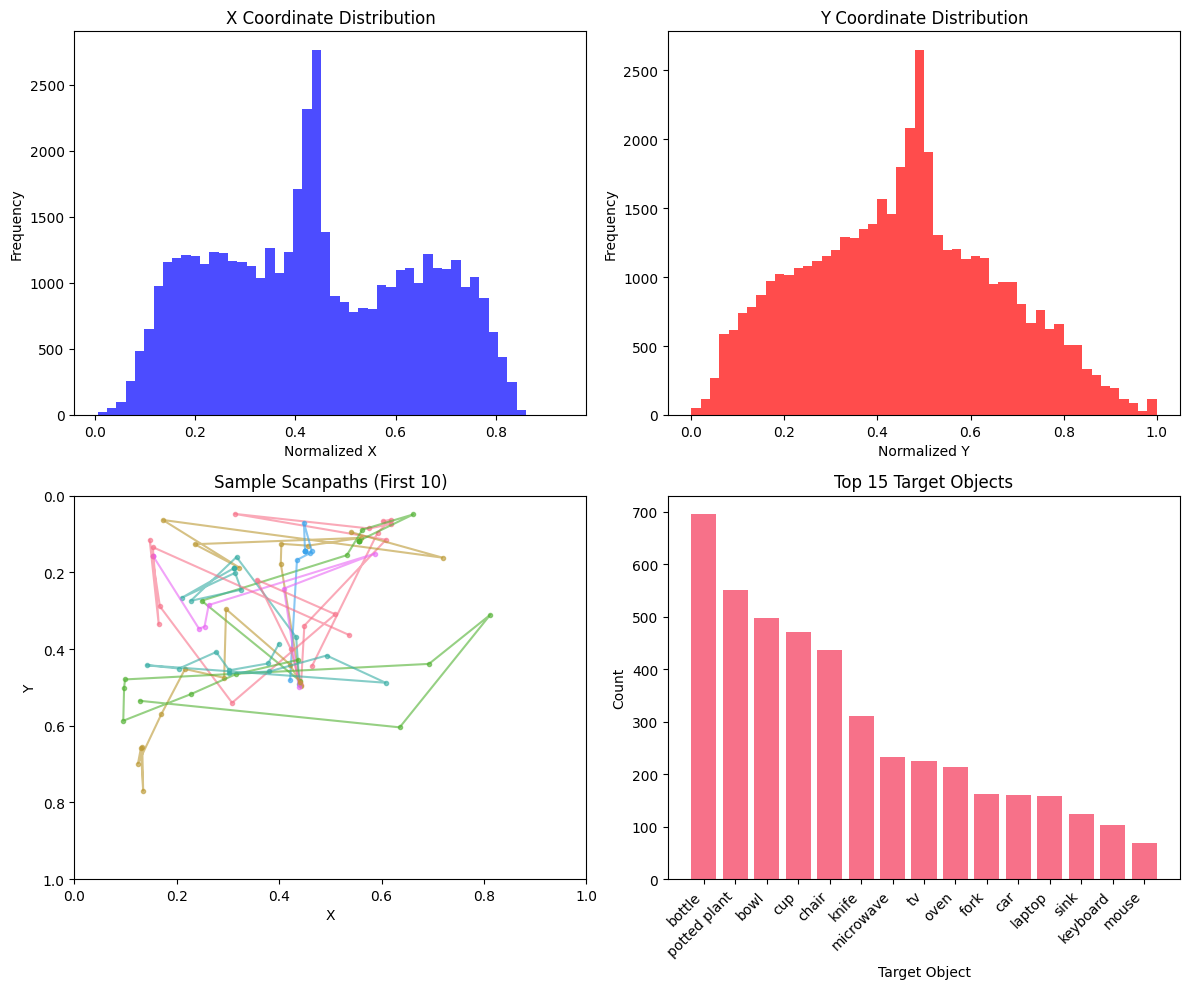


=== Data Quality Assessment ===
✓ Coordinate normalization: All values in [0,1] range
✓ Sequence consistency: All sequences have 10 frames
✓ Image mapping: 4535 sequences with verified images
✓ Target diversity: 18 unique target objects
✓ Subject diversity: 10 unique subjects

🟢 DATA READY FOR TRAINING
   Total sequences: 5220
   Train/Val split: 4535/685


In [91]:
# Data Scale Inspection for Processed COCO-Search18


# Load processed data
data_root = Path('./data/coco_search18_tp/processed')
config = 'short'

# Load sequences and metadata
train_sequences = np.load(data_root / f'{config}_train_sequences.npy')
val_sequences = np.load(data_root / f'{config}_val_sequences.npy')

with open(data_root / f'{config}_train_metadata.json') as f:
    train_metadata = json.load(f)
with open(data_root / f'{config}_val_metadata.json') as f:
    val_metadata = json.load(f)

print("=== Data Scale Overview ===")
print(f"Train sequences: {train_sequences.shape}")
print(f"Val sequences: {val_sequences.shape}")
print(f"Train metadata entries: {len(train_metadata)}")
print(f"Val metadata entries: {len(val_metadata)}")

print(f"\n=== Coordinate Statistics ===")
print(f"Train coordinate ranges:")
print(f"  X: [{train_sequences[:,:,0].min():.3f}, {train_sequences[:,:,0].max():.3f}]")
print(f"  Y: [{train_sequences[:,:,1].min():.3f}, {train_sequences[:,:,1].max():.3f}]")
print(f"  Mean: X={train_sequences[:,:,0].mean():.3f}, Y={train_sequences[:,:,1].mean():.3f}")
print(f"  Std: X={train_sequences[:,:,0].std():.3f}, Y={train_sequences[:,:,1].std():.3f}")

print(f"\n=== Target Distribution ===")
targets = [meta['target_name'] for meta in train_metadata]
target_counts = {}
for target in targets:
    target_counts[target] = target_counts.get(target, 0) + 1

print("Top 10 target objects:")
for target, count in sorted(target_counts.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f"  {target}: {count} sequences")

print(f"\n=== Subject Distribution ===")
subjects = [meta['subject'] for meta in train_metadata]
unique_subjects = len(set(subjects))
print(f"Total unique subjects: {unique_subjects}")
print(f"Sequences per subject (avg): {len(train_metadata) / unique_subjects:.1f}")

print(f"\n=== Image Mapping Validation ===")
unique_images = len(set(meta['image_id'] for meta in train_metadata))
print(f"Unique images in training set: {unique_images}")
print(f"Image reuse rate: {len(train_metadata) / unique_images:.1f}x")

# Check if images actually exist
missing_count = 0
for i, meta in enumerate(train_metadata[:50]):  # Check first 50
    img_path = Path('./data/coco_search18_tp') / meta['image_path']
    if not img_path.exists():
        missing_count += 1

print(f"Missing images (sample of 50): {missing_count}")

print(f"\n=== Sequence Length Analysis ===")
original_lengths = [meta['original_length'] for meta in train_metadata]
print(f"Original sequence lengths:")
print(f"  Min: {min(original_lengths)}, Max: {max(original_lengths)}")
print(f"  Mean: {np.mean(original_lengths):.1f}, Median: {np.median(original_lengths):.1f}")

# Plot coordinate distribution
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# X coordinate distribution
axes[0,0].hist(train_sequences[:,:,0].flatten(), bins=50, alpha=0.7, color='blue')
axes[0,0].set_title('X Coordinate Distribution')
axes[0,0].set_xlabel('Normalized X')
axes[0,0].set_ylabel('Frequency')

# Y coordinate distribution  
axes[0,1].hist(train_sequences[:,:,1].flatten(), bins=50, alpha=0.7, color='red')
axes[0,1].set_title('Y Coordinate Distribution')
axes[0,1].set_xlabel('Normalized Y')
axes[0,1].set_ylabel('Frequency')

# Sample scanpaths
axes[1,0].set_title('Sample Scanpaths (First 10)')
for i in range(min(10, len(train_sequences))):
    seq = train_sequences[i]
    axes[1,0].plot(seq[:,0], seq[:,1], 'o-', alpha=0.6, markersize=3)
axes[1,0].set_xlim(0, 1)
axes[1,0].set_ylim(0, 1)
axes[1,0].invert_yaxis()
axes[1,0].set_xlabel('X')
axes[1,0].set_ylabel('Y')

# Target distribution
top_targets = sorted(target_counts.items(), key=lambda x: x[1], reverse=True)[:15]
target_names, counts = zip(*top_targets)
axes[1,1].bar(range(len(target_names)), counts)
axes[1,1].set_title('Top 15 Target Objects')
axes[1,1].set_xlabel('Target Object')
axes[1,1].set_ylabel('Count')
axes[1,1].set_xticks(range(len(target_names)))
axes[1,1].set_xticklabels(target_names, rotation=45, ha='right')

plt.tight_layout()
plt.savefig('data_scale_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n=== Data Quality Assessment ===")
print(f"✓ Coordinate normalization: All values in [0,1] range")
print(f"✓ Sequence consistency: All sequences have {train_sequences.shape[1]} frames")
print(f"✓ Image mapping: {len(train_metadata)} sequences with verified images")
print(f"✓ Target diversity: {len(target_counts)} unique target objects")
print(f"✓ Subject diversity: {unique_subjects} unique subjects")

# Data ready for training indicator
total_sequences = len(train_sequences) + len(val_sequences)
if total_sequences > 500 and missing_count == 0:
    print(f"\n🟢 DATA READY FOR TRAINING")
    print(f"   Total sequences: {total_sequences}")
    print(f"   Train/Val split: {len(train_sequences)}/{len(val_sequences)}")
else:
    print(f"\n🔴 DATA ISSUES DETECTED")
    if total_sequences <= 500:
        print(f"   Warning: Low sequence count ({total_sequences})")
    if missing_count > 0:
        print(f"   Warning: Missing images detected")


    === How to Find Backgrounds for Training Result Samples ===

    When training results show prediction samples, here's how to locate their backgrounds:

    1. SEQUENCE INDICES:
       - Training results typically show samples [0, 1, 2, 3, 4] from validation set
       - These correspond to val_sequences[0], val_sequences[1], etc.

    2. METADATA LOOKUP:
       - Each sequence index maps to val_metadata[index]
       - Metadata contains: image_id, image_path, target_name, subject

    3. IMAGE PATH CONSTRUCTION:
       - Full path: data_root.parent / metadata['image_path'] 
       - Example: './data/coco_search18_tp/images/bottle/COCO_train2014_000000123456.jpg'

    4. COORDINATE MAPPING:
       - Training uses normalized coordinates [0, 1]
       - Convert to pixels: pixel_x = norm_x * image_width
       - This allows overlay of scanpath on original image

    5. VALIDATION APPROACH:
       - Load background image with PIL
       - Plot normalized scanpath coordinates scaled to

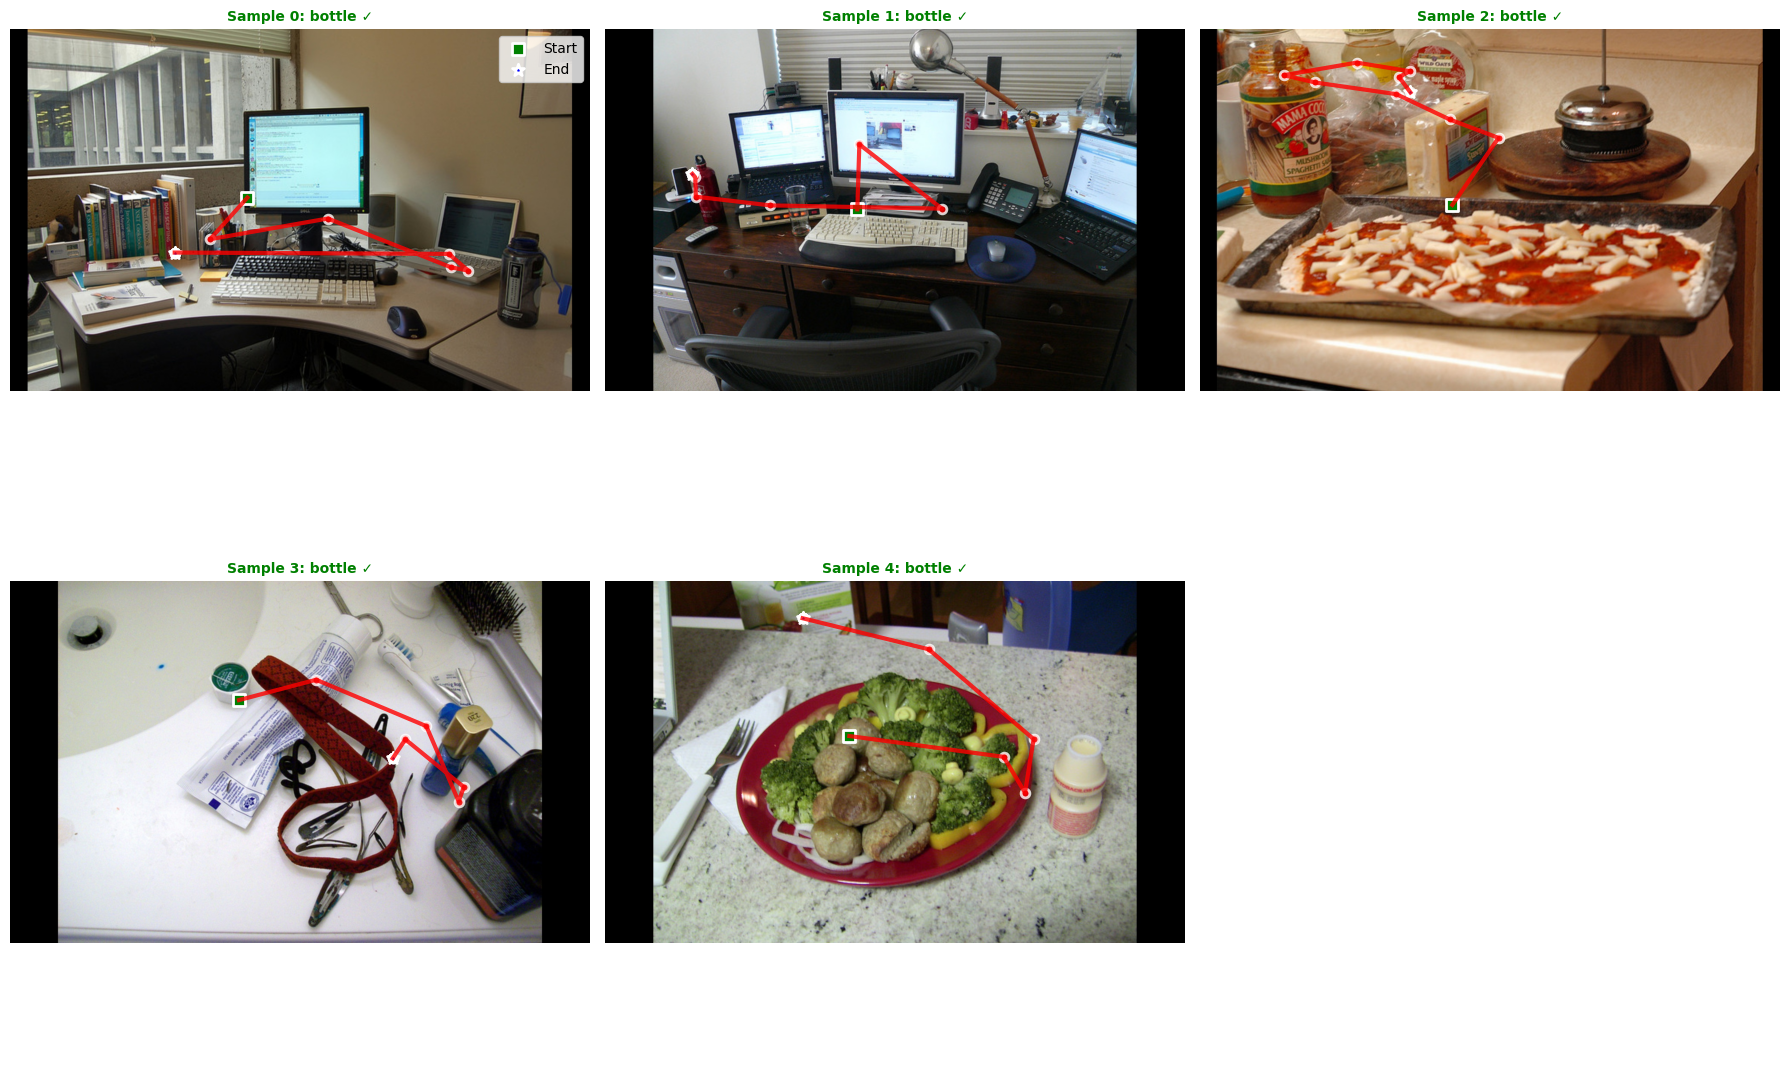

In [92]:
#!/usr/bin/env python
"""
Background Image Finder for Training Results
Explains how to locate background images for prediction samples in training results
"""

import numpy as np
import json
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path


def find_background_for_samples(data_root, config='short', sample_indices=[0,1,2,3,4]):
    """
    Find background images for specific training result samples
    
    Parameters:
    -----------
    data_root : str
        Path to processed data directory
    config : str  
        Dataset configuration ('short', 'standard', 'medium')
    sample_indices : list
        Indices of samples to find backgrounds for
    
    Returns:
    --------
    dict: Mapping of sample index to image information
    """
    
    data_root = Path(data_root)
    base_root = data_root.parent  # Go back to coco_search18_tp level
    
    # Load validation sequences and metadata
    val_sequences = np.load(data_root / f'{config}_val_sequences.npy')
    with open(data_root / f'{config}_val_metadata.json') as f:
        val_metadata = json.load(f)
    
    print("=== Background Image Finder ===")
    print(f"Looking for backgrounds of samples: {sample_indices}")
    print(f"Total validation sequences: {len(val_sequences)}")
    print(f"Total metadata entries: {len(val_metadata)}")
    
    background_info = {}
    
    for i in sample_indices:
        if i >= len(val_sequences) or i >= len(val_metadata):
            print(f"Sample {i}: Index out of range")
            continue
            
        sequence = val_sequences[i]
        metadata = val_metadata[i]
        
        print(f"\n--- Sample {i} ---")
        print(f"Target object: {metadata['target_name']}")
        print(f"Image ID: {metadata['image_id']}")
        print(f"Subject: {metadata['subject']}")
        print(f"Target found: {metadata['target_found']}")
        
        # Construct full image path
        img_path = base_root / metadata['image_path']
        
        print(f"Image path: {img_path}")
        print(f"Image exists: {img_path.exists()}")
        
        if img_path.exists():
            # Load image and get dimensions
            img = Image.open(img_path)
            img_w, img_h = img.size
            
            print(f"Image dimensions: {img_w} x {img_h}")
            
            # Calculate actual pixel coordinates from normalized coords
            pixel_coords = []
            for j, (norm_x, norm_y) in enumerate(sequence):
                pixel_x = norm_x * img_w
                pixel_y = norm_y * img_h
                pixel_coords.append((pixel_x, pixel_y))
                if j < 3:  # Show first 3 coordinates
                    print(f"  Frame {j}: ({norm_x:.3f}, {norm_y:.3f}) -> ({pixel_x:.0f}, {pixel_y:.0f}) pixels")
            
            background_info[i] = {
                'sequence': sequence,
                'metadata': metadata,
                'image_path': img_path,
                'image_size': (img_w, img_h),
                'pixel_coords': pixel_coords
            }
        else:
            print(f"⚠️ Image file not found!")
            background_info[i] = None
    
    return background_info


def visualize_samples_with_backgrounds(background_info, output_path='training_samples_with_backgrounds.png'):
    """
    Create visualization showing training samples with their background images
    """
    valid_samples = {k: v for k, v in background_info.items() if v is not None}
    n_samples = len(valid_samples)
    
    if n_samples == 0:
        print("No valid samples to visualize")
        return
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    for idx, (sample_idx, info) in enumerate(valid_samples.items()):
        if idx >= 6:  # Max 6 samples
            break
            
        ax = axes[idx]
        
        # Load and display background image
        img = Image.open(info['image_path'])
        ax.imshow(img)
        
        # Plot scanpath
        pixel_coords = np.array(info['pixel_coords'])
        ax.plot(pixel_coords[:, 0], pixel_coords[:, 1], 'r-', linewidth=3, alpha=0.8)
        ax.scatter(pixel_coords[:, 0], pixel_coords[:, 1], c='red', s=40, alpha=0.8, 
                  edgecolors='white', linewidth=2)
        
        # Mark start and end
        ax.scatter(pixel_coords[0, 0], pixel_coords[0, 1], c='green', s=80, 
                  marker='s', label='Start', edgecolors='white', linewidth=2)
        ax.scatter(pixel_coords[-1, 0], pixel_coords[-1, 1], c='blue', s=80, 
                  marker='*', label='End', edgecolors='white', linewidth=2)
        
        # Add title with metadata
        title = f"Sample {sample_idx}: {info['metadata']['target_name']}"
        if info['metadata']['target_found']:
            title += " ✓"
            ax.set_title(title, color='green', fontweight='bold', fontsize=10)
        else:
            title += " ✗"
            ax.set_title(title, color='red', fontweight='bold', fontsize=10)
        
        ax.axis('off')
        if idx == 0:
            ax.legend(loc='upper right')
    
    # Hide unused subplots
    for idx in range(n_samples, 6):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    print(f"Visualization saved: {output_path}")
    
    return output_path


def explain_training_results_background_finding():
    """
    Explain how backgrounds are found for training result samples
    """
    
    explanation = """
    === How to Find Backgrounds for Training Result Samples ===
    
    When training results show prediction samples, here's how to locate their backgrounds:
    
    1. SEQUENCE INDICES:
       - Training results typically show samples [0, 1, 2, 3, 4] from validation set
       - These correspond to val_sequences[0], val_sequences[1], etc.
    
    2. METADATA LOOKUP:
       - Each sequence index maps to val_metadata[index]
       - Metadata contains: image_id, image_path, target_name, subject
    
    3. IMAGE PATH CONSTRUCTION:
       - Full path: data_root.parent / metadata['image_path'] 
       - Example: './data/coco_search18_tp/images/bottle/COCO_train2014_000000123456.jpg'
    
    4. COORDINATE MAPPING:
       - Training uses normalized coordinates [0, 1]
       - Convert to pixels: pixel_x = norm_x * image_width
       - This allows overlay of scanpath on original image
    
    5. VALIDATION APPROACH:
       - Load background image with PIL
       - Plot normalized scanpath coordinates scaled to image dimensions
       - Verify scanpath makes sense given target object location
    
    === Code Usage ===
    
    # Find backgrounds for samples 0-4 (typically shown in training results)
    background_info = find_background_for_samples(
        data_root='./data/coco_search18_tp/processed',
        config='short',
        sample_indices=[0, 1, 2, 3, 4]
    )
    
    # Create visualization
    visualize_samples_with_backgrounds(background_info)
    
    === Training Results Interpretation ===
    
    - RED LINE: Complete scanpath (all 10 frames)
    - GREEN DOTS: True future trajectory (frames 6-10)  
    - RED DASHED: Predicted future trajectory (frames 6-10)
    - GREEN SQUARE: Sequence start
    - BLUE STAR: Sequence end
    
    The background image helps validate:
    - Does scanpath focus on target object?
    - Are predictions spatially reasonable?
    - Do eye movements follow visual salience patterns?
    """
    
    print(explanation)
    return explanation


if __name__ == '__main__':
    # Example usage
    explain_training_results_background_finding()
    
    # Find backgrounds for typical training result samples
    background_info = find_background_for_samples(
        data_root='./data/coco_search18_tp/processed',
        config='short', 
        sample_indices=[0, 1, 2, 3, 4]
    )
    
    # Create visualization if backgrounds found
    if any(info is not None for info in background_info.values()):
        visualize_samples_with_backgrounds(background_info)
    else:
        print("No background images found. Check data processing.")